# Molecular Mechanics Parameters for a Protein-Ligand Complex

In this exercise, we will build molecular mechanics models of the adenosine receptor A2A (ADORA2A) with a variety of ligands that have different signaling efficacy ($E_{max}$). $EC_{50}$ describes the amount of ligand required to induce a response. $E_{max}$ describes the strength of a cellular response at a saturating concentration of ligand. The same ligand can have different pharmacodynamic properties for different pathways, for example with different G proteins through the $\mu$ opioid receptor [1].

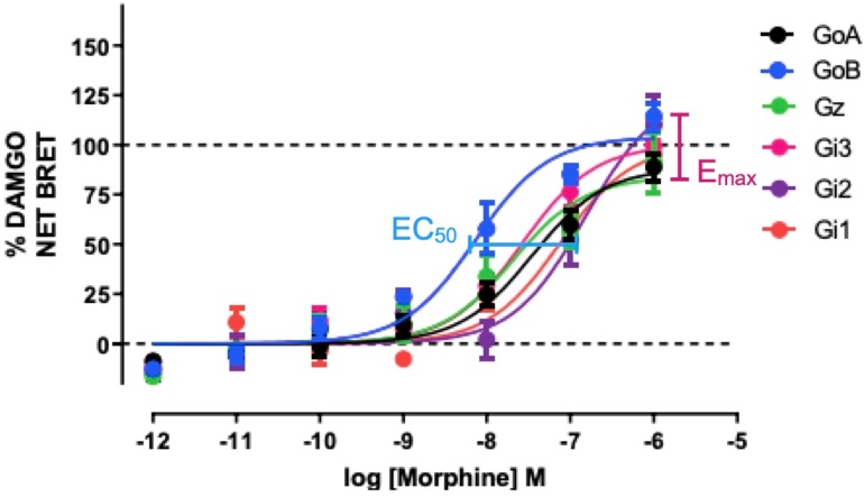

Fig. 1. G protein signaling of morphine at the MOR.

[1] Malcolm, N. J.; Palkovic, B.; Sprague, D. J.; Calkins, M. M.; Lanham, J. K.; Halberstadt, A. L.; Stucke, A. G.; McCorvy, J. D. Mu-Opioid Receptor Selective Superagonists Produce Prolonged Respiratory Depression. iScience 2023, 26 (7), 107121. https://doi.org/10.1016/j.isci.2023.107121.

I would like us to study the mechanisms of signal activation. Guo et al [2] found that the efficacy of a number of ADORA2A ligands is highly correlated with the logarithm of the residence time ($t_r$ = 1/k$_{off}$). My group recently found that the efficacy of a number of MOR ligands is highly correlated with the equilibrium probability of intracellular pocket conformations observed in molecular dynamics simulations [3]. I would like to evaluate whether efficacy of ADORA2A ligands is *also* correlated with the equilibrium probability of intracellular pocket conformations. In this exercise, we will build models of ADORA2A with different ligands. In subsequent exercises, we will perform and analyze molecular dynamics simulations with enhanced sampling.

We will use [Bridgeport](https://github.com/CCBatIIT/Bridgeport), a package being developed by research group that wraps multiple other packages to perform these tasks for different types of ligands. In addition to preparing small molecule ligands that are already in the provided PDB structure, it can prepare analogs of these ligands. It is also meant to prepare peptide and peptidomimetics.

[2] Guo, D.; Mulder‐Krieger, T.; IJzerman, A. P.; Heitman, L. H. Functional Efficacy of Adenosine A 2A Receptor Agonists Is Positively Correlated to Their Receptor Residence Time. British J Pharmacology 2012, 166 (6), 1846–1859. https://doi.org/10.1111/j.1476-5381.2012.01897.x.

[3] Cooper, D. A.; DePaolo-Boisvert, J.; Nicholson, S. A.; Gad, B.; Minh, D. D. L. Intracellular Pocket Conformations Determine Signaling through the μ Opioid Receptor. bioRxiv April 3, 2024. https://doi.org/10.1101/2024.04.03.588021.

Assuming that you are reading this Notebook on Github, you will need to download it to your account on SDSC Expanse. To do that, log onto the Expanse User Portal, select *Shell*, and paste the following commands into the terminal:

```bash
mkdir -p ~/exercises
cd ~/exercises
curl -L -o 07-System_Preparation.ipynb https://raw.githubusercontent.com/daveminh/Chem456-2026S/refs/heads/main/exercises/07-System_Preparation.ipynb
```

Unlike recent exercises we will need to set up a new environment before starting JupyterLab. You can do that by following the steps in Part 1.

The exercise will be graded based on submitting your answers to the questions after ```-->``` on Canvas.

# Part 0. Conda environment setup on SDSC Expanse

First, we need to set up a new conda environment

## 1) Log onto the Expanse User Portal → *Shell*.

## 2) Start an interactive CPU job (recommended for installs)

```bash
srun --partition=shared --account=iit130 --nodes=1 --ntasks=1 --cpus-per-task=4 --mem=8G --time=01:00:00 --pty bash
```

## 3) Create and register a conda environment

We’ll create a new environment named `bpsim`. Paste the following commands in to the terminal:
```bash
source "$HOME/miniconda3/etc/profile.d/conda.sh"
# Create the environment
mamba create -n bpsim -c conda-forge -c salilab -c defaults ambertools biopython h5py matplotlib mdanalysis mdtraj modeller netcdf4 nglview=4.0.0 numpy openbabel openff-forcefields openff-interchange openff-toolkit openff-units openmm packmol pandas parmed pdbfixer pip pydantic pytables py3Dmol rdkit scikit-learn -y
```
<!--
# mamba create -n psi -c conda-forge -c salilab -c defaults ambertools=23.3 biopython h5py matplotlib mdanalysis=2.7 mdtraj modeller netcdf4 numpy openbabel openff-forcefields=2024.01.0 openff-interchange=0.3.18 openff-toolkit=0.15.1 openff-units=0.2.1 openmm=8.1 packmol pandas parmed pip pydantic[version='>=2.6'] pytables python=3.10 rdkit=2023.09 scikit-learn -y
 -->

If you have problems creating the environment, you may need to remove it using `mamba env remove --name bpsim` and install it again.

To register the kernel so it appears in JupyterLab, paste the following commands into the terminal:
```bash
conda activate bpsim
python -m ipykernel install --user --name bpsim --display-name "Python (bpsim)"
```

## 4) Download the Bridgeport repository
```bash
mkdir -p ~/github
cd ~/github
git clone https://github.com/CCBatIIT/Bridgeport.git
```

Once these commands are complete, you may end the interactive CPU job with the `exit` command.

## 5) Start a JupyterLab session

The command to launch a JupyterLab session is similar to previous exercises, but differs in the `conda-env` argument.
```bash
/cm/shared/apps/sdsc/galyleo/galyleo launch --account iit130 --partition shared --cpus 4 --memory 8 --time-limit 02:00:00 --interface lab --conda-env bpsim --conda-init "$HOME/miniconda3/etc/profile.d/conda.sh"
```

# Part 1. Package imports and setup

Once you have started your JupyterLab session, we need to import and set up packages. First, set up one of the Bridgeport dependencies, UCSF Modeller, which performs homology modeling. You should [obtain an academic license](https://salilab.org/modeller/registration.html) and replace the variable `modeller_license`. If there is a newer version of Modeller, you may need to update `modeller_dir`.

In [ ]:
import os
modeller_dir = os.path.join(os.environ.get('CONDA_PREFIX'),'lib','modeller-10.8')
modeller_config = modeller_dir + '/modlib/modeller/config.py'
modeller_license = ''

if not os.path.isfile(modeller_config):
    F = open(modeller_config,'w')
    F.write("install_dir = r'" + modeller_dir + "'\n")
    F.write("license = r'" + modeller_license + "'\n")
    F.close()

import modeller

Install pdb2pqr

In [ ]:
! pip install pdb2pqr

Now import Bridgeport and required packages

In [ ]:
import os, sys
from datetime import datetime

from interactive.interactive_utils import *
from utils.utils import write_FASTA
from chimpss.bridgeport import Bridgeport
from rdkit.Chem.Draw import rdDepictor
import nglview

In [ ]:
working_dir = os.path.join(os.environ.get('HOME'), 'exercises', '07')
! mkdir -p {working_dir}

json_dict = {'working_dir': working_dir}

# Part 2. Building a model of the solvated protein 

We will build protein structural models using UCSF MODELLER, which is wrapped by Bridgeport. High-resolution crystal structures of ADORA2A in complex with many ligands are available in the PDB. All of the ligands described in Guo *et. al.* [2] or close analogs are represented. The crystal structures contain conformations of the orthosteric binding site that are appropriate for binding the specific ligands. Homology modelling is needed because of missing atoms and residues and because of mutations that were engineered to increase thermal or crystallographic stability. For example, [PDB entry 5wf5 contains an domain inserted from another protein, endolysin](https://www.rcsb.org/sequence/5WF5).

We will prepare homology models of ADORA2A using two templates. Primary templates will be high-resolution crystallographic structures. The secondary template will be an AlphaFold 2 model. In our current application, it is advantageous to model most of the protein based on a single structure to preserve the conformation of the active site. [The AlphaFold 2 model](https://alphafold.ebi.ac.uk/entry/P29274) provides reasonable structures of most the missing loops and tails.

## Target sequence

The full sequence of ADORA2A is available under UniProt entry [P29274](https://www.uniprot.org/uniprotkb/P29274/entry#sequences). The [AlphaFold 2 structure](https://alphafold.ebi.ac.uk/entry/P29274) has low confidence in the first four residues of the N terminus and beyond residue 313 in the C terminus; [nearly all high-resolution structures were based on constructs containing residues 1-317 or less.](https://www.uniprot.org/uniprotkb/P29274/entry#structure) Thus, we will model residues 1-313.

In [ ]:
receptor_gene = 'ADORA2A'
sequence = """
MPIMGSSVYITVELAIAVLAILGNVLVCWAVWLNSNLQNVTNYFVVSLAAADIAVGVLAI
PFAITISTGFCAACHGCLFIACFVLVLTQSSIFSLLAIAIDRYIAIRIPLRYNGLVTGTR
AKGIIAICWVLSFAIGLTPMLGWNNCGQPKEGKNHSQGCGEGQVACLFEDVVPMNYMVYF
NFFACVLVPLLLMLGVYLRIFLAARRQLKQMESQPLPGERARSTLQKEVHAAKSLAIIVG
LFALCWLPLHIINCFTFFCPDCSHAPLWLMYLAIVLSHTNSVVNPFIYAYRIREFRQTFR
KIIRSHVLRQQEPFKAAGTSA""".replace('\n','')

# Write FASTA
! mkdir -p {os.path.join(working_dir, 'fasta')}
fasta_path = os.path.join(working_dir, 'fasta', f'{receptor_gene}.fasta')
write_FASTA(sequence, receptor_gene, fasta_path)

## Template structures

We will download three protein structures from several sources: the PDB (primary template), the AlphaFold structural database (secondary template), and the [Orientation of Proteins in Membranes (OPM) database](https://opm.phar.umich.edu/proteins/2808) (reference). OPM provides information about where the protein should be placed into the membrane.

Look up the [class spreadsheet](https://iit0-my.sharepoint.com/:x:/g/personal/dminh_illinoistech_edu/IQD0yN4dhNNXQYc4XHowDejBAfygYI3latkJJvd6JuCyOrc?e=3Q2zda) to see which ligands you will model and your primary template. You will model two complexes: one with the ligand in the PDB structure and an analog of the ligand. Modify the variable `template1_id` to match your PDB ID.

In [ ]:
input_pdb_dir = os.path.join(working_dir,'input_pdb')
! mkdir -p {input_pdb_dir}

template1_id = "8rwd"
template2_id = "P29274"
opm_id = "4uhr"
template1_url = f"https://files.rcsb.org/download/{template1_id}.cif.gz"
template2_url = f"https://alphafold.ebi.ac.uk/files/AF-{template2_id}-F1-model_v6.pdb"
opm_url = f"https://opm-assets.storage.googleapis.com/pdb/{opm_id}.pdb"

import requests
for (id, url) in [(template1_id, template1_url), (template2_id, template2_url), (opm_id, opm_url)]:
  if id==template1_id:
    path = f"{input_pdb_dir}/{id}.cif.gz"
  else:
    path = f"{input_pdb_dir}/{id}.pdb"
  if not os.path.isfile(path):
    r = requests.get(url)
    r.raise_for_status()
    with open(path, "wb") as f:
        f.write(r.content)
  else:
    print(f"{path} has already been downloaded")
  if id==template1_id:
    ! gunzip -fk {input_pdb_dir}/{id}.cif.gz 
    ! obabel {input_pdb_dir}/{id}.cif -O {input_pdb_dir}/{id}_obabel.pdb

from Bio.PDB import MMCIFParser
from Bio.PDB import PDBIO

parser = MMCIFParser()
structure = parser.get_structure(template1_id, f"{input_pdb_dir}/{template1_id}.cif")
for res in structure.get_residues():
    if len(res.resname)>3:
        res.resname = res.resname[:3]
io = PDBIO()
io.set_structure(structure)
io.save(f"{input_pdb_dir}/{template1_id}_biopython.pdb")

Your primary template may include an insertion such that the residue indices do not correspond to the canonical residue numbers in UNIPROT. This can be seen in the PDB entry for [8RWD](https://www.rcsb.org/structure/8RWD):

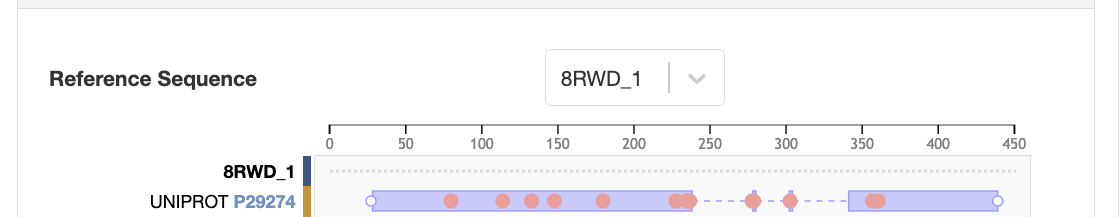

If this is the case, switch the reference sequence to the UNIPROT and click on each segment of the sequence to see how the PDB residue indices correspond to the UNIPROT indices.

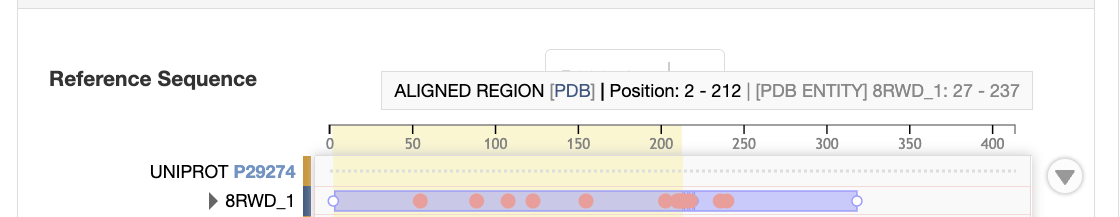

## --> Define a dictionary that maps from original PDB to UNIPROT indices. 

If there are no insertions, you will have the same range for both. The python `range` function stops one number before the `stop` value.

If there is inconsistency between the atom orders in the pdb files from openbabel and biopython, you may want to set `pdb_to_use = 'biopython'`. This loses some molecule connectivity information.
If your primary template has more than one receptor chain, you may want to set `keepChain` to the chain ID, e.g. `keepChain = 'A'`.

In [ ]:
mapping = dict(zip(list(range(27,238)) + list(range(340,439)), # Original PDB indicies
                   list(range(2,213)) + list(range(219,318)))) # UNIPROT indicies
pdb_to_use = 'openbabel'
keepChain = None

# Create a new file where the residues are renumbered according to the mapping.
import MDAnalysis as mda
u_openbabel = mda.Universe(f"{input_pdb_dir}/{template1_id}_obabel.pdb")
u_biopython = mda.Universe(f"{input_pdb_dir}/{template1_id}_biopython.pdb")

if pdb_to_use == 'openbabel':
    u = u_openbabel    
elif pdb_to_use == 'biopython':
    u = u_biopython

if keepChain is not None:
    u = u.select_atoms(f'chainID {keepChain}')

if pdb_to_use == 'openbabel':
    # Use chain IDs from biopython, which openbabel does not preserve
    for (a_openbabel, a_biopython) in zip(u_openbabel.atoms, u_biopython.atoms):
        a_openbabel.chainID = a_biopython.chainID
elif pdb_to_use == 'biopython':    
    # Use numbering from openbabel, which biopython does not preserve
    for (r_o, r_o_chainIDs, r_b, r_b_chainIDs) in zip(u_openbabel.residues, u_openbabel.residues.chainIDs, \
                                                      u_biopython.residues, u_biopython.residues.chainIDs):
        if r_o.resname==r_b.resname:
            r_b.resid = r_o.resid
        else:
            print(f"{r_o.resname} {r_o_chainIDs[0]} and {r_b.resname} {r_b_chainIDs[0]} do not match")

# Renumber based on defined mapping
print("Original residue numbering")
print(u.residues.resids)
for residue in u.select_atoms("protein").residues:
    if residue.resid in mapping.keys():
        residue.resid = mapping[residue.resid]
    else:
        # All residues not in the mapping are given a large residue index and subsequently ignored
        residue.resid += 50000
for residue in u.select_atoms("not protein").residues:
    residue.resid += 1
print("New residue numbering")
print(u.residues.resids)
with mda.Writer(f"{input_pdb_dir}/{template1_id}.pdb") as f:
    f.write(u.select_atoms("resid 0:50000"))

Bridgeport requires information about your primary template in the Protein and Ligand dictionaries, environment (including reference structure), and repair process:

**Protein Input**

- *input_pdb_dir*: (str) path to directory where the *input_pdb* can be found. (Previously defined variable)
- *input_pdb*: (str) name of input structure. (Previously defined variable)
- *chain*: (str) of chain to use from *input_pdb* to align
    
**Ligand Input** (fill in this information for the ligand in the primary template)

- *name*: (str) a name for your ligand, as described in the spreadsheet.
- *resname*: (str) resname of ligand found in *input_pdb*. If the ligand, is a peptide set to "False".
- *chainid*: (str) if ligand is a peptide, specify the letter code that denotes the ligand, if not set to "False".
- *smiles*: (str) the smiles string of the ligand. SMILES strings define the atoms and connectivity of a molecule. SMILES strings for all ligands in PDB entries can be accessed by following the [ligands tab, e.g. for 5wf5](https://www.rcsb.org/ligand-validation/5WF5/UKA), to the [ligand summary and definition, e.g. for UKA](https://www.rcsb.org/ligand/UKA). Below you should define `smiles` based on the "Isomeric SMILES" field for the ligand from your primary template.

**Environment**

- *alignment_ref*: (str) path to refence structure to align input structure to
- *reference_chain*: (List[str]) of chains of the *reference_pdb* to use in the alignment process
- "membrane": If membrane should be specified choose "true", and make sure that "alignment_ref" argument is the appropriate OPM structure. Default is false.
- "pH": Specify the pH. Default is 7.0.
- "ion_strength": Specify the concentration of NaCl ions (in Molar). Default is 0.15 M.

**Repair**
- *receptor_gene*: (str) protein gene name
- *fasta_path*: (str) path to the FASTA sequence of the protein you are trying to model (Previously defined variable). 
- *secondary_template*: (str) Path to secondary template PDB file, e.g. from AlphaFold, used to model large regions that are missing from the primary template (Previously defined variable).
- *engineered_resids*: (list of int) Resids that are known engineered mutations in the crystal pdb. Adding this argument may prevent sequence errors in the RepairProtein section of Bridgeport.
- *tails*: If not False, residues outside of these indices will be removed. EX: [30, 479]
- *loops*: If not False, (list of list of int) lower and upper bounds of loops to optimize with MODELLER during refinement. Can usually be skipped with a AlphaFold secondary template.

You can use the spreadsheet, nglview (see below), the PDB web site, and/or the PDB files to find this information.

## --> Complete the Protein and Ligand dictionaries

In [ ]:
# Related to the primary template
json_dict['Protein'] = {
    'input_pdb_dir': input_pdb_dir, # Previously defined
    'input_pdb': template1_id + '.pdb', # Previously defined
    'chain': 'A'} # See nglview

lig_smiles = "CCN1C(=O)N(CC)c2nc(/C=C/c3ccc(OC)c(O)c3)n(C)c2C1=O" # See PDB web site
json_dict['Ligand'] = {
    'name': 'A1H3H', # See spreadsheet
    'resname': 'A1H', # Check input pdb
    'chainid': False,
    'smiles': lig_smiles}

# Related to the reference structure
json_dict['Environment'] = {
    'alignment_ref': os.path.join(input_pdb_dir, f'{opm_id}.pdb'),
    'reference_chain': ['A'], # See nglview
    'membrane':True,
    'pH':7.0, 
    'ion_strength':0.15}

# Related to protein repair with MODELLER
json_dict['RepairProtein'] = {
    'fasta_path': fasta_path, # Previously defined variable
    'working_dir': os.path.join(working_dir, 'modeller_intermediates'),
    'tails': [1,314], 
    'loops': False,
    'secondary_template': os.path.join(input_pdb_dir, template2_id + '.pdb'), # Previously defined
    'engineered_resids': None}

# Visualize the reference structure, primary template, and secondary template. 
# If dictionaries have been defined properly, then the code should execute but the structures will be unaligned.
import nglview as nv
view = nv.NGLWidget()
view.add_component(json_dict['Environment']['alignment_ref'])
view[0].clear_representations()
view[0].add_representation("cartoon", selection=":" + json_dict['Environment']['reference_chain'][0], color="red")
view.add_component(os.path.join(json_dict['Protein']['input_pdb_dir'], json_dict['Protein']['input_pdb']))
view[1].clear_representations()
view[1].add_representation("cartoon", selection=":" + json_dict['Protein']['chain'], color="green")
view[1].add_representation("ball+stick", selection=json_dict['Ligand']['resname'])
view.add_component(json_dict['RepairProtein']['secondary_template'])
view[2].clear_representations()
view[2].add_representation("cartoon", color="blue")
view.display(gui=True)

## Aligning the primary template to the reference structure

In [ ]:
# Initiate Bridgeport instance
input_json_fn = f'07/{template1_id}-{json_dict['Ligand']['resname']}.json'
write_json(json_dict, input_json_fn)
start = datetime.now()
BP = Bridgeport(input_json_fn, verbose=False)

# Align
BP.align_to_reference()

# Visualize the primary template and reference structure
import nglview as nv
view = nv.NGLWidget()
view.add_component(json_dict['Environment']['alignment_ref'])
view[0].clear_representations()
view[0].add_representation("cartoon", selection=":" + json_dict['Environment']['reference_chain'][0], color="red")
view.add_component(BP.aligned_pdb)
view[1].clear_representations()
view[1].add_representation("cartoon", selection=":" + json_dict['Protein']['chain'], color="green")
view[1].add_representation("ball+stick", selection=json_dict['Ligand']['resname'])
view.display(gui=True)

## --> Take a screenshot of the primary template (green) aligned to the reference structure (red)

## Repairing the protein

In [ ]:
BP.separate_lig_prot()
BP.repair_protein()

# Visualize the repaired protein and primary template
import nglview as nv
view = nv.NGLWidget()
view.add_component(BP.aligned_pdb)
view[0].clear_representations()
view[0].add_representation("cartoon", selection=":" + json_dict['Protein']['chain'], color="green")
view[0].add_representation("ball+stick", selection=json_dict['Ligand']['resname'])
view.add_component(os.path.join(BP.prot_only_dir, BP.name + '.pdb'))
view[1].clear_representations()
view[1].add_representation("cartoon", selection=":" + json_dict['Protein']['chain'], color="blue")
view[1].add_representation("ball+stick", selection=json_dict['Ligand']['resname'])
view.display(gui=True)

## --> Take a screenshot of the repaired protein (blue) and primary template aligned to the reference structure (green). Describe differences between the two.

## Building the membrane and solvent environment

Often, molecular systems are simulated in a box filled with solvent such as water. These boxes are of finite size, which results in problems for molecules at or near the box boundaries. With which molecules should those interact? Periodic boundary conditions can avoid such boundary artifacts by simulating a theoretically infinite system. Molecules at one boundary of the box thereby interact with molecules at the boundary on the other side of the box. This mimics a situation, in which the simulation box is surrounded by replicas of itself. When visualizing such MD simulations, one can often observe that particles leave the box at one side (Fig. 3). However, they re-appear at the same time on the other side of the box with the same velocity. For simulations under periodic boundary conditions, it is recommended to use a simulation box large enough, so that the simulated macromolecule does not come into contact with neighboring images of itself.

![MD_water.gif](https://github.com/volkamerlab/teachopencadd/raw/d1ded86bb2c82ef088cc5145d0bcb997f6eab7dd/teachopencadd/talktorials/018_md_simulation/images/MD_water.gif)

**Figure 3**: Molecular dynamics simulation of water molecules with periodic boundary conditions (Kmckiern via [Wikimedia](https://commons.wikimedia.org/wiki/File:MD_water.gif)).

We will use Bridgeport to build the solvent and membrane environment. The following code writes a configuration file for Bridgeport, creates an Bridgeport instance, and builds the environment.

In [ ]:
BP.add_environment()

# Visualize the entire system (protein, membrane, water, and ions)
import nglview as nv
view = nv.NGLWidget()
view.add_component(BP.env_pdb)
view.add_representation("ball+stick", selection="hetero")
view.display(gui=True)

# Part 3. Preparing the complete system

Bridgeport has a number of arguments related to parameterizing the ligand:

- *small_molecule_params (bool)*: If true, treat ligand like a small molecule. Default is True.
- *sanitize (bool)*: If True, sanitize molecule with rdkit. Default is True. Only applicable if small_molecule_params is True. 
- *removeHs (bool)*: If True, remove any hydrogens that may be present. Default is True. Only applicable if small_molecule_params is True.
- *proximityBonding* (bool): If True, use rdkit's 'proximityBonding' method to load rdkit molecule. 
- *pH (float)*: pH to protonate a peptide ligand. Default is 7.0.
- *nstd_resids (List[int])*: List of nonstandard resids to conserve from input structure. 
- *neutral_Cterm (bool)*: If true, neutralize the C-terminus of a peptide ligand. Only applicable is small_molecule_params is False.

For this exercise, you do not need to change them.

In [ ]:
BP.input_params['Ligand']['small_molecule_params'] = True
BP.input_params['Ligand']['sanitize'] = True
BP.input_params['Ligand']['removeHs'] = True
BP.input_params['Ligand']['nstd_resids'] = None
BP.input_params['Ligand']['pH'] = 7.0
BP.input_params['Ligand']['neutral_Cterm'] = False

if pdb_to_use == 'openbabel':
    BP.input_params['Ligand']['proximityBonding'] = False  
elif pdb_to_use == 'biopython':
    BP.input_params['Ligand']['proximityBonding'] = True

## Building the ligand from the primary template

In [ ]:
BP.ligand_prep()

# Visualize the ligand (sdf or pdb)
import nglview as nv
view = nv.NGLWidget()
if hasattr(BP, 'lig_sdf'):
    view.add_component(BP.lig_sdf)
else:
    view.add_component(BP.lig_pdb)
view.display(gui=True)

## Preparing the system with the ligand from the primary template

We can generate a PDB (structure) and XML (molecular mechanics force field parameters) for the protein-ligand complex in membrane, water, and ions.

Force fields describe the forces between atoms within and between molecules. They are parametric equations with components for different forces (bond stretching, van-der-Waals and more). The parameter values are usually derived experimentally and change for each MD scenario, depending on the molecules involved and the simulation settings. The result is a mathematical description of the energy landscape of the system, in which the forces acting on each particle result from the gradient of the potential energy with respect to the coordinates of the atoms.

Several force fields are available, each with its own characteristics ([_J Chem Inf Model_ (2018), **58**(3), 565-578](https://doi.org/10.1021/acs.jcim.8b00042)). In this notebook, we will use a member of the AMBER force field family, which are widely used for modeling proteins. Their functional form is:

$$V(r^N) = \sum_{i \in  bonds}k_{bi} (l_i-l^0_i)^2 + \sum_{i \in  angles}k_{ai}(\theta_i - \theta^0_i)^2 + \sum_{i\in torsions} \sum_n \frac{1}{2} V_i^n[1+cos(nw_i-\gamma_i)]$$
$$+ \sum_{j=1}^{N-1}\sum_{I=j+1}^{N} f_{ij}\in ij [(\frac{r^0_{ij}}{r_{ij}})^{12}-2(\frac{r^0_{ij}}{r_{ij}})^{6}]+\frac{q_iq_j}{4\pi \in_0 r_{ij}}$$

The formula consists of a sum of different components. The first three components contain information about bond lengths, angles and torsions (intramolecular forces). The last component describes intermolecular, non-bonded forces like van-der-Waals forces and electrostatic interactions. The various parameters, denoted by a superscript 0, depend on the force field used and vary between all members of the AMBER force field family. Note that these force fields assume fixed-charge particles and do not allow polarization, nor do they consider how a local charge influences its surroundings.

The following visual representation of force fields components shows the same concepts in a more intuitive way.

![MM_PEF.png](https://github.com/volkamerlab/teachopencadd/raw/d1ded86bb2c82ef088cc5145d0bcb997f6eab7dd/teachopencadd/talktorials/018_md_simulation/images/MM_PEF.png)

**Figure 2**: Components of a molecular mechanics force field (Edboas via [Wikimedia](https://commons.wikimedia.org/w/index.php?curid=4194424)).

Common force fields like AMBER have parameters for amino acids, nucleic acids, water and ions and usually offer several options to choose from depending on your aim. We will use AMBER for protein, water, and membrane and the OpenFF forcefield for ligands. The following code will assign parameters to all the atoms in the system.

In [ ]:
BP.generate_systems()

# Store complete json that would reproduce the system preparation
input_json_fn = f'07/{template1_id}-{json_dict['Ligand']['resname']}.json'
write_json(BP.input_params, input_json_fn)

print('WROTE:', input_json_fn)
print('TOOK:', datetime.now() - start)

# Visualize the entire system (protein, ligand, membrane, water, and ions)
import nglview as nv
view = nv.NGLWidget()
view.add_component(BP.final_pdb)
view.add_representation("ball+stick", selection="hetero")
view.display(gui=True)

## Building an analog

Bridgeport also has the ability to build systems with ligands that are analogs of the ligand in a primary template. These are the ligands from Guo et. al. [2]:

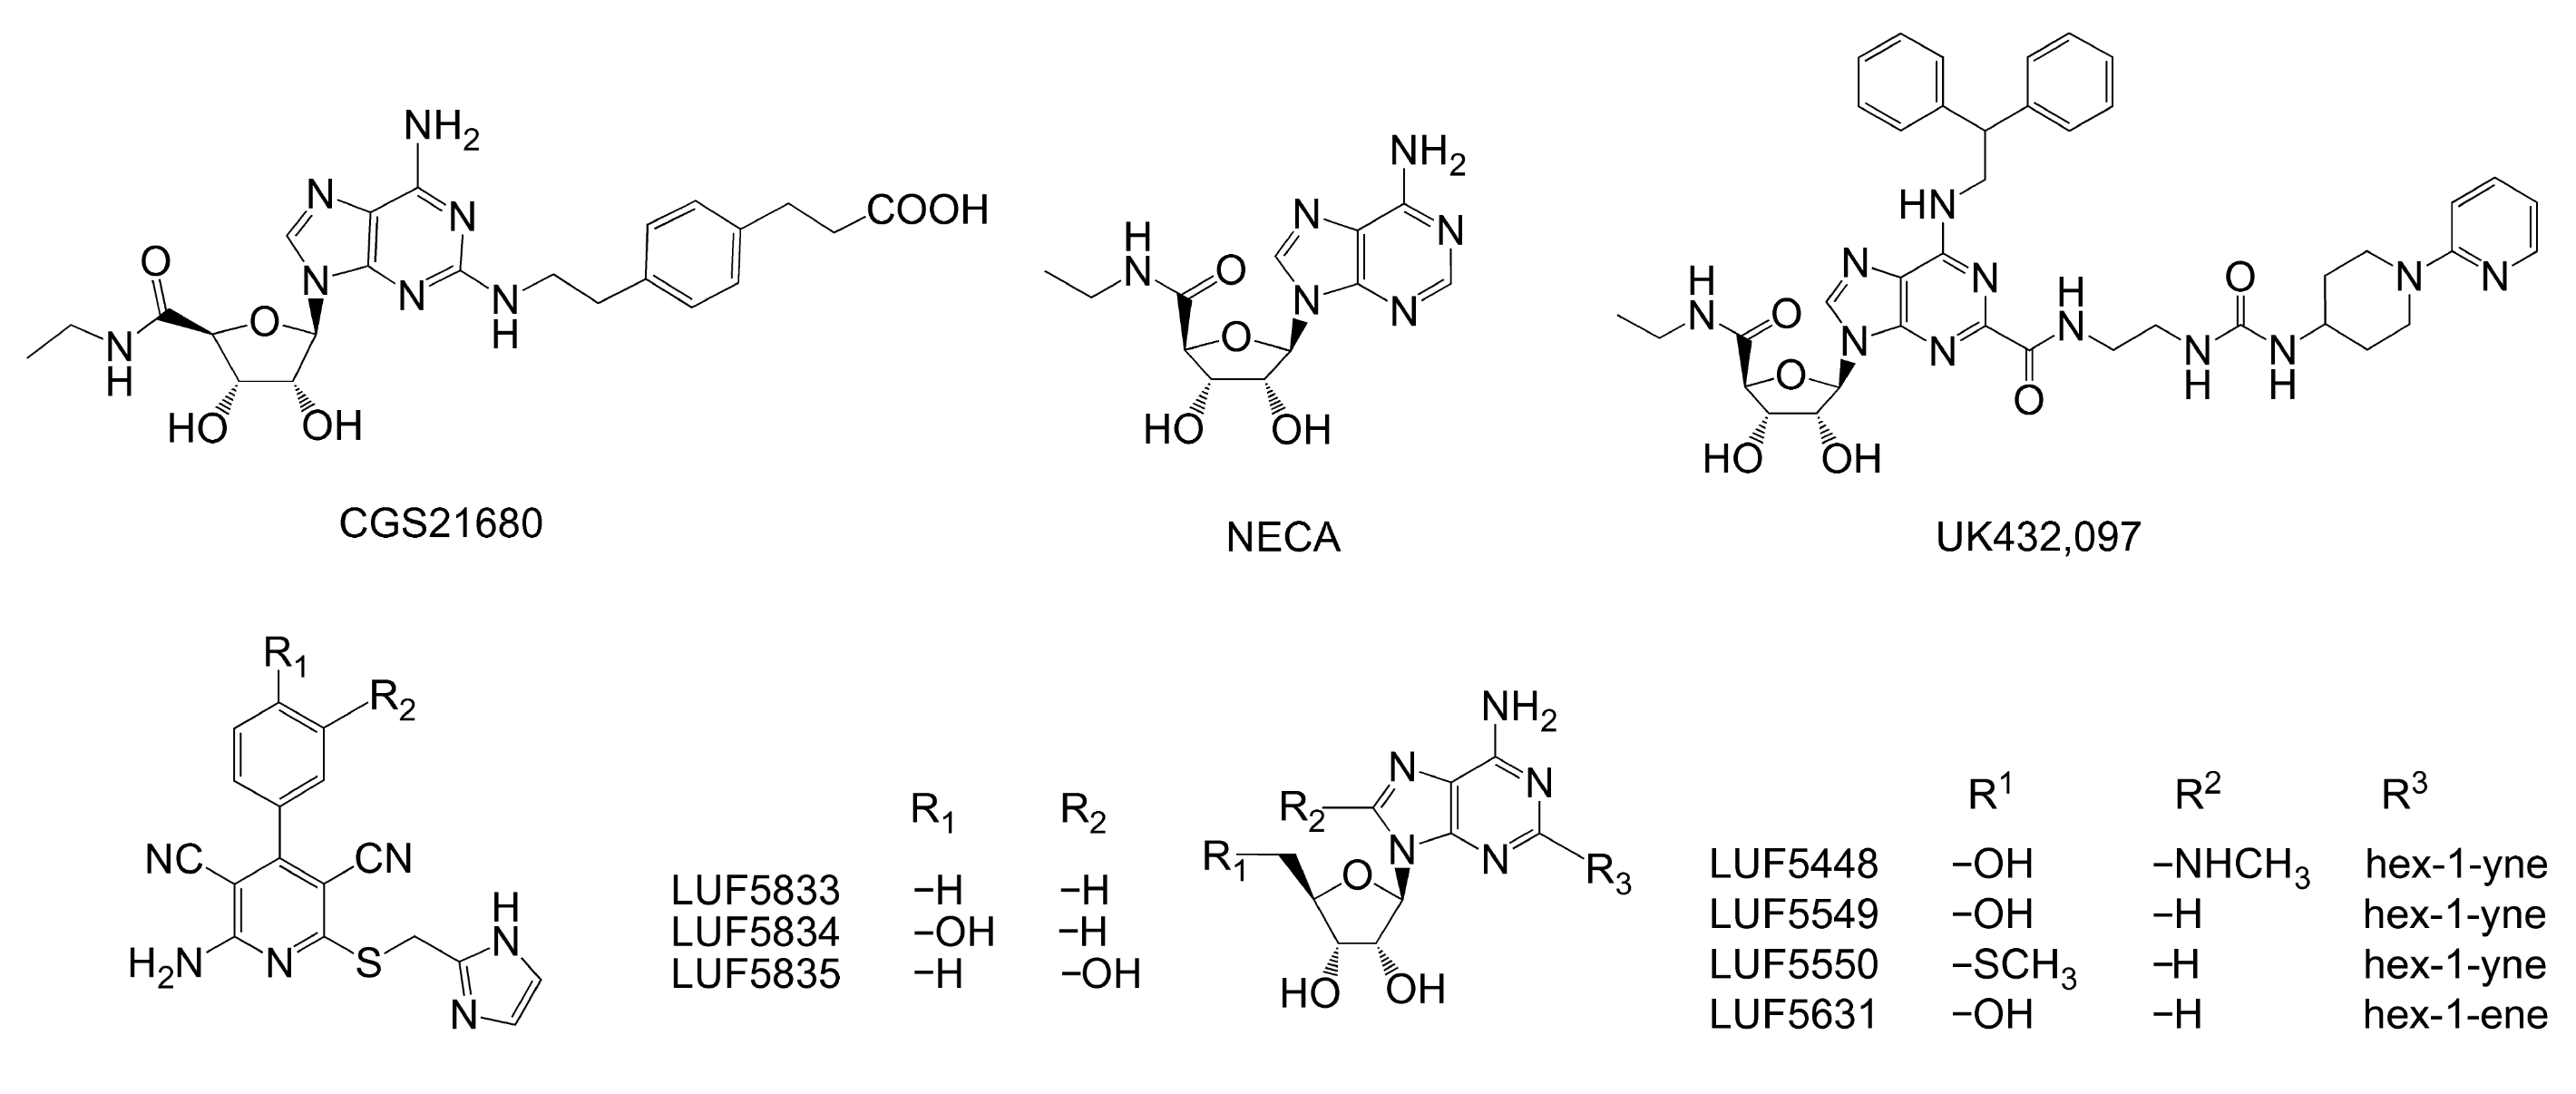

We need to define the SMILES string for your analog. A convenient tool to do this is [PubChem](https://pubchem.ncbi.nlm.nih.gov/). You can copy and paste the ligand from your primary template, search, and then find the "Edit Structure" button. You should modify the ligand from the primary template into your assigned ligand.

In [ ]:
# Show information about the ligand in the primary template
BP.input_params['Ligand']

## --> What is the SMILES string of your analog? Take a screenshot of the 2D structure.

In [ ]:
# Define parameters for the analog
# The `add_atoms` and `remove_atoms` can manually add or remove atoms from the mapping.
BP.input_params['Ligand']['Analogue'] = {
    'name': 'MSX-2', 
    'smiles': "C#CN3C(=O)N(CCCO)C1=C([N](C(=N1)C=CC2=CC(=CC=C2)O[H])C)C3=O",
    'add_atoms': False, 
    'remove_atoms': False}

# Defines the maximum common substructure (MCS) of the ligand from the primary template and its analog
# First shows the 2D structure of the analog
# Next both ligands are shown with the MCS highlighted. Both ligands are indexed to help define `add_atoms` and `remove_atoms` as needed.
BP.get_analogue_MCS()

In [ ]:
# Analog preparation parameters
BP.input_params['Ligand']['Analogue']['align_all'] = True # Uses atoms in `add_atoms` for alignment
BP.input_params['Ligand']['Analogue']['rmsd_thresh'] = 1. # RMSD threshold that analogue conformation must reach during alignment to be accepted as a permittable structure
BP.input_params['Ligand']['Analogue']['n_conformers'] = 100 # Number of analog conformers to generate

BP.build_analogue_complex() 
BP.analogue.visualize_alignment()

In [ ]:
BP.ligand_prep()

# Visualize the ligand (sdf or pdb)
import nglview as nv
view = nv.NGLWidget()
if hasattr(BP, 'lig_sdf'):
    view.add_component(BP.lig_sdf)
else:
    view.add_component(BP.lig_pdb)
view.display(gui=True)

In [ ]:
BP.generate_systems()

# Change ligand smiles back
BP.input_params['Ligand']['smiles'] = lig_smiles

# Store complete json that would reproduce the system preparation
input_json_fn = f'07/{template1_id}-{BP.input_params['Ligand']['Analogue']['name']}.json'
write_json(BP.input_params, input_json_fn)

print('WROTE:', input_json_fn)
print('TOOK:', datetime.now() - start)

In [ ]:
# Visualize the entire system (protein, ligand, membrane, water, and ions)
import nglview as nv
view = nv.NGLWidget()
view.add_component(BP.final_pdb)
view.add_representation("ball+stick", selection="hetero")
view.display(gui=True)

## --> Take a screen shot of your ligand in the binding pocket (hiding water).

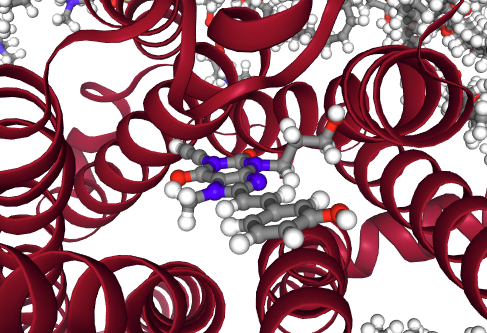

# References

- Review on force fields ([_J Chem Inf Model_ (2018), **58**(3), 565-578](https://doi.org/10.1021/acs.jcim.8b00042))
- Summarized statistical knowledge from Pierre-Simon Laplace ([Théorie Analytique des Probabilités _Gauthier-Villars_ (1820), **3**)](https://archive.org/details/uvrescompltesde31fragoog/page/n15/mode/2up)
- Inspired by a notebook form Jaime Rodríguez-Guerra ([github](https://github.com/jaimergp/uab-msc-bioinf/blob/master/MD%20Simulation%20and%20Analysis%20in%20a%20Notebook.ipynb))
- Repositories of [OpenMM](https://github.com/openmm/openmm) and [OpenMM Forcefields](https://github.com/openmm/openmmforcefields), [RDKit](https://github.com/rdkit/rdkit), [PyPDB](https://github.com/williamgilpin/pypdb), [MDTraj](https://github.com/mdtraj/mdtraj), [PDBFixer](https://github.com/openmm/pdbfixer)
- Wikipedia articles about [AMBER](https://en.wikipedia.org/wiki/AMBER) and [force fields](https://en.wikipedia.org/wiki/Force_field_(chemistry)) in general